In [1]:
from pathlib import Path
import sys
import json
import uuid
from datetime import datetime
import os

ROOT_DIR = Path.cwd().parent.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from src.db_conn import DatabaseConnection
from config.settings import (
    DATA_DIR,
    MODELS_DIR,
    FORECAST_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


In [2]:
master = pd.read_csv(f'{DATA_DIR}/master.csv')

display(master)

,sale_date,net_price,non_work_day,is_month_end,close_month_zone
0,2024-01-02,"719,422.63",0,0,0
1,2024-01-03,"992,292.59",0,0,0
2,2024-01-04,"802,011.48",0,0,0
3,2024-01-05,"484,853.02",0,0,0
4,2024-01-06,"60,058.17",0,0,0
...,...,...,...,...,...
860,2026-05-11,"1,790,415.58",0,0,0
861,2026-05-12,"2,139,962.69",0,0,0
862,2026-05-13,"1,245,428.49",0,0,1
863,2026-05-14,"1,656,746.25",0,0,1


In [11]:
#definimos train, test, validation
train_cutoff = '2026-03-31'
validation_start = '2026-04-01'
validation_end = '2026-04-30'

In [12]:
#seoaramos la variable target de las exogenas
y = master['net_price']
X = master[['non_work_day', 'is_month_end', 'close_month_zone']]

display(X)
display(y)

,non_work_day,is_month_end,close_month_zone
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
860,0,0,0
861,0,0,0
862,0,0,1
863,0,0,1


0      719422.63312100
1      992292.59227400
2      802011.48393000
3      484853.02474800
4       60058.16750900
            ...       
860   1790415.58209100
861   2139962.69431400
862   1245428.48707000
863   1656746.24965200
864    646434.79219400
Name: net_price, Length: 865, dtype: float64

In [13]:
y.index = pd.to_datetime(master['sale_date'])
X.index = pd.to_datetime(master['sale_date'])
#split de datos
y_train = y[:train_cutoff]
y_val   = y[validation_start:validation_end]

X_train = X[:train_cutoff]
X_val   = X[validation_start:validation_end]

display(X_train)
display(y_train)

,non_work_day,is_month_end,close_month_zone
sale_date,,,
2024-01-02,0,0,0
2024-01-03,0,0,0
2024-01-04,0,0,0
2024-01-05,0,0,0
2024-01-06,0,0,0
...,...,...,...
2026-03-27,0,0,1
2026-03-28,0,0,0
2026-03-29,0,0,0


sale_date
2024-01-02    719422.63312100
2024-01-03    992292.59227400
2024-01-04    802011.48393000
2024-01-05    484853.02474800
2024-01-06     60058.16750900
                   ...       
2026-03-27   1237289.26356300
2026-03-28         0.00000000
2026-03-29         0.00000000
2026-03-30   2718817.07469200
2026-03-31   2964747.96838300
Name: net_price, Length: 820, dtype: float64

In [14]:
def save_metadata(*,
                  order: list = [0,0,0],
                  seasonal_order: list = [0,0,0,7],
                  enforce_stationarity: bool = False,
                  enforce_invertibility: bool = False,
                  fit_obj,
                  file_path: str = f'{MODELS_DIR}/sarimax.json',
                  model_id: str = None,
                  ) -> dict:

    try:
        start_date = fit_obj.model.data.dates[0].strftime('%Y-%m-%d')
        end_date = fit_obj.model.data.dates[-1].strftime('%Y-%m-%d')
    except (AttributeError, TypeError):
        start_date = str(fit_obj.model.data.row_labels[0])
        end_date = str(fit_obj.model.data.row_labels[-1])

    model_metadata = {
        "train_period": {
            "start_date": start_date,
            "end_date": end_date
        },
        "hyperparameters": {
            "order": order,
            "seasonal_order": seasonal_order,
            "enforce_stationarity": enforce_stationarity,
            "enforce_invertibility": enforce_invertibility
        },
        "metrics": {
            "aic": float(fit_obj.aic),
            "bic": float(fit_obj.bic),
            "log_likelihood": float(fit_obj.llf),
            "nobs": int(fit_obj.nobs)
        },
        "coeficientes": fit_obj.params.to_dict()
    }

    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            try:
                data_historica = json.load(f)
            except json.JSONDecodeError:
                data_historica = {}
    else:
        data_historica = {}

    if model_id is None:
        model_id = f'{datetime.now().date()}_{uuid.uuid4()}'

    data_historica[model_id] = model_metadata

    with open(file_path, "w") as f:
        json.dump(data_historica, f, indent=4)

    print(f'Metadata saved for model: {model_id}\n')
    return model_metadata

In [15]:
#primeras pruebas con parámetros
p_1=1
d_1=0 #obtenido gracia a ADF
q_1=1

P_1=1
D_1=0
Q_1=1

order_1 = (p_1, d_1, q_1)

s=7 #estacionalidad semanal ya comprobada
s_order_1 = (P_1, D_1, Q_1,s)
model_1 = SARIMAX(
    y_train,
    exog=X_train,
    order=order_1,
    seasonal_order=s_order_1,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_1 = model_1.fit(disp=False)

print(fit_res_1.summary())

meta_1 = save_metadata(
    order=list(order_1),
    seasonal_order=list(s_order_1),
    fit_obj=fit_res_1,
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -11910.820
Date:                           Sun, 24 May 2026   AIC                          23837.639
Time:                                   21:19:39   BIC                          23875.225
Sample:                               01-02-2024   HQIC                         23852.069
                                    - 03-31-2026                                         
Covariance Type:                             opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
non_work_day      1309.9661   6766.240      0.194      0.846    -1.2e+04    1.46e+04
is_month_end      2.472e+

#### interpretación de resultados model_1

* Cierre Comercial.

    La variable `is_month_end` cuenta con un p-value perfecto de `0.000`. Esto revela que el último día laborable del mes es un fenómeno de facturación masiva aislado que aporta casi $2.5M extras sobre la tendencia base.

* El Efecto de la Zona de Cierre (`close_month_zone`).

    Mantiene un impacto sólido de +$1,512,000 pesos (`P>|z| = 0.000`) durante los dos días laborables previos al cierre. Esto demuestra un comportamiento escalonado: la última semana del mes arranca con un empuje de +$1.5M diarios y culmina con un clímax de +$2.4M en la última jornada útil.

* Warning [2].

    El aviso de inestabilidad en los errores estándar `condition number 1.36e+30` es muy alto. La causa matemática es la variable `non_work_day` (`P>|z| = 0.865`). Al incluir una bandera de días no laborales junto con un orden estacional de rezago 7 (`s=7`), se genera una redundancia estructural, ya que el componente autorregresivo estacional del modelo ya mapea y absorbe matemáticamente las caídas fijas de los fines de semana.

* Componente de promedio movil `ma.L1`.

    El parámetro de media móvil diaria tradicional arrojó un p-value de `0.816`. Esto significa que los errores del día anterior no tienen un impacto arrastrable en las ventas del día de hoy, haciendo que este parámetro sea puro ruido dentro del algoritmo.

#### Parámetrso para el siguiente modelo (Model 2)

Para limpiar las alertas matemáticas, reducir el sobreajuste y estabilizar los errores estándar antes de la exportación final, se propone transicionar hacia la configuración `SARIMAX(1, 0, 0)x(1, 0, 1, 7)`:

* Parte No Estacional: `order=(1, 0, 0)`
* $p = 1$ (Autorregresivo - AR): Mantenemos un rezago diario de corto plazo. Aunque en el primer modelo marcó un p-value de `0.065` (ligeramente arriba del umbral del 5%), es altamente probable que se estabilice y vuelva significativo al remover el ruido que provocaba la interacción con el componente MA.
* $d = 0$ (Diferenciación): Se mantiene en cero fijo, respaldado por la prueba de Dickey-Fuller Aumentada que demostró la estacionariedad de la serie tras la imputación de anomalías.
* $q = 0$ (Media Móvil - MA): Se reduce a cero. Al comprobarse que `ma.L1` no es estadísticamente significativo (`0.816`), removerlo simplifica la matriz de covarianza y ayuda a mitigar la singularidad del modelo.


* Parte Estacional: `seasonal_order=(1, 0, 1, 7)`
* Se preserva intacto debido a la significancia perfecta (`0.000`) de los rezagos estacionales de 7 días. El modelo requiere mantener tanto el término autorregresivo estacional ($P=1$) como la media móvil estacional ($Q=1$) para poder replicar matemáticamente los valles fijos de los domingos.

In [16]:
#eliminacion de non_work_day
X_optimized = X_train[['is_month_end', 'close_month_zone']]

display(X_optimized)

,is_month_end,close_month_zone
sale_date,,
2024-01-02,0,0
2024-01-03,0,0
2024-01-04,0,0
2024-01-05,0,0
2024-01-06,0,0
...,...,...
2026-03-27,0,1
2026-03-28,0,0
2026-03-29,0,0


In [17]:
p_2, d_2, q_2 = 1, 0, 0
P_2, D_2, Q_2, s_2 = 1, 0, 1, 7

order_2 = (p_2, d_2, q_2)
s_order_2 = (P_2, D_2, Q_2, s_2)

model_2 = SARIMAX(
    y_train,
    exog=X_optimized,
    order=order_2,
    seasonal_order=s_order_2,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_2 = model_2.fit(disp=False)
print(fit_res_2.summary())


meta_2 = save_metadata(
    order=list(order_2),
    seasonal_order=list(s_order_2),
    fit_obj=fit_res_2,
)


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood              -11924.855
Date:                             Sun, 24 May 2026   AIC                          23861.709
Time:                                     21:19:46   BIC                          23889.906
Sample:                                 01-02-2024   HQIC                         23872.533
                                      - 03-31-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end      2.472e+06   3.54e+04     69.836      0.000     2.4e+06    2.54e+06
close_mon

#### Interpretación de resultados model_2

* Cierre Comercial y Zona de Cierre.

    Tanto `is_month_end` como `close_month_zone` mantuvieron su significancia perfecta de `0.000` y sus coeficientes intactos, $2.43M y $1.51M respectivamente. Esto demuestra que el impacto de nuestras variables comerciales es totalmente robusto y no dependía del ruido de las otras variables que se eliminaron.

* Consistencia del componente Autorregresivo `ar.L1`.

    Al remover el parámetro `ma.L1` (que era puro ruido), el componente autorregresivo `ar.L1` se estabilizó por completo, pasando de un p-value dudoso de `0.058` a un `0.000`. Ahora el modelo demuestra que la venta de hoy tiene una memoria directa del 33.9% respecto a la venta del día anterior.

* Residuos (Ljung-Box).

    El valor de `Prob(Q)` se ubicó en `0.80`. Al mantenerse significativamente por encima de 0.05, confirmamos con un alto nivel de confianza que los residuos del modelo siguen siendo ruido blanco de comportamiento aleatorio. El modelo no ha perdido capacidad predictiva al simplificarse.

* Warning [2].

    A pesar de eliminar la redundancia de los días no laborables, el aviso de matriz casi singular persiste con un `condition number 9.12e+29`. El origen ya no es la colinealidad, sino un problema de escala de magnitudes.

    Se están pasando al modelo variables exógenas binarias (ceros y unos) mientras que la variable objetivo `net_price` está configurada en valores de millones de pesos. Esta disparidad de escalas estresa la matriz matemática del algoritmo durante la optimización.

#### Parámetros para model_3

Para eliminar la alerta de la matriz singular, estabilizar los errores estándar y dejar el modelo listo para producción, se propone mantener la arquitectura estructural pero aplicando una transformación de escala en los datos:

* Transformación de Escala en la Variable Objetivo: `y_scaled = y / 1,000,000`
* En lugar de obligar al modelo a optimizar valores de $4,600,000 contra banderas de 0 y 1, escalaremos la serie para que el target se exprese en millones de pesos, por ejemplo, $4.63M se convierte en 4.63. Esto homologa las magnitudes numéricas, elimina los problemas de convergencia en la matriz de covarianza y limpia por completo el Warning [2] sin alterar la matemática del modelo.


* Conservación de Parámetros: `order=(1, 0, 0)` y `seasonal_order=(1, 0, 1, 7)`
* Dado que todos los componentes actuales (`ar.L1`, `ar.S.L7` y `ma.S.L7`) arrojaron p-values perfectos de `0.000`, la arquitectura matemática ya es la óptima. Solo se ajustará la escala del input.

In [18]:
pd.options.display.float_format = '{:.8f}'.format
y_scaled = y/1000000

y_train = y_scaled[:train_cutoff]
y_test  = y_scaled[validation_start:]

display(y_scaled)

sale_date
2024-01-02   0.71942263
2024-01-03   0.99229259
2024-01-04   0.80201148
2024-01-05   0.48485302
2024-01-06   0.06005817
                ...    
2026-05-11   1.79041558
2026-05-12   2.13996269
2026-05-13   1.24542849
2026-05-14   1.65674625
2026-05-15   0.64643479
Name: net_price, Length: 865, dtype: float64

In [19]:
order_3 = (1, 0, 0)
seasonal_order_3 = (1, 0, 1, 7)
model_3 = SARIMAX(
    y_train,
    exog=X_optimized,
    order=order_3,
    seasonal_order=seasonal_order_3,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_3 = model_3.fit(disp=False)
print(fit_res_3.summary())

meta_3 = save_metadata(
    order=list(order_3),
    seasonal_order=list(seasonal_order_3),
    fit_obj=fit_res_3,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                -452.275
Date:                             Sun, 24 May 2026   AIC                            916.551
Time:                                     21:20:21   BIC                            944.748
Sample:                                 01-02-2024   HQIC                           927.375
                                      - 03-31-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.3954      0.049     28.733      0.000       1.300       1.491
close_mon

In [21]:
order_5 = (1, 1, 1)
seasonal_order_5 = seasonal_order_3

model_5 = SARIMAX(
    y_train,
    exog=X_optimized[['is_month_end', 'close_month_zone']],
    order=order_5,
    seasonal_order=seasonal_order_5,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_5 = model_5.fit(disp=False)
print(fit_res_5.summary())

meta_5 = save_metadata(
    order=list(order_5),
    seasonal_order=list(seasonal_order_5),
    fit_obj=fit_res_5,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         net_price   No. Observations:                  820
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                -456.345
Date:                           Sun, 24 May 2026   AIC                            926.691
Time:                                   21:21:37   BIC                            959.570
Sample:                               01-02-2024   HQIC                           939.314
                                    - 03-31-2026                                         
Covariance Type:                             opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.3958      0.050     28.114      0.000       1.299       1.493
close_month_zone     0.37

In [23]:
order_6 = (1, 0, 0)
seasonal_order_6 = (0,1,1,7)

model_6 = SARIMAX(
    y_train,
    exog=X_optimized[['is_month_end', 'close_month_zone']],
    order=order_6,
    seasonal_order=seasonal_order_6,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_6 = model_6.fit(disp=False)
print(fit_res_6.summary())

meta_6 = save_metadata(
    order=list(order_6),
    seasonal_order=list(seasonal_order_6),
    fit_obj=fit_res_6,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood                -452.652
Date:                             Sun, 24 May 2026   AIC                            915.304
Time:                                     21:28:13   BIC                            938.758
Sample:                                 01-02-2024   HQIC                           924.311
                                      - 03-31-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.3989      0.049     28.698      0.000       1.303       1.494
close_mon

#### Selección del modelo final (1,0,0), (0,1,1,7)

Tras múltiples iteraciones de entrenamiento y validación de hiperparámetros, la arquitectura que demostró el mejor rendimiento predictivo sobre la facturación fue el modelo $\text{SARIMAX}$ con orden general $(1, 0, 0)$ y orden estacional $(0, 1, 1, 7)$, optimizado mediante las características exógenas de fin de mes.

#### Interpretación Matemática de la Arquitectura

Esta configuración define el comportamiento del pronóstico a través de dos dimensiones temporales:

* Componente No Estacional $(1, 0, 0)$.

    Establece que el comportamiento base de las ventas diarias conserva una memoria corta. El parámetro $p=1$ dicta una dependencia autorregresiva directa con el volumen facturado el día inmediatamente anterior $t-1$. En el muy corto plazo, la serie no requiere diferenciación ($d=0$) ni promedios móviles diarios $q=0$.

* Componente Estacional $(0, 1, 1, 7)$.

    Captura y neutraliza los ciclos semanales de la operación comercial. Se aplica una diferenciación estacional de primer grado $D=1$ que modela la serie en función del cambio neto respecto al mismo día de la semana anterior. Además, incorpora un término de media móvil estacional $Q=1$ que ajusta el pronóstico actual basándose de forma estocástica en el error de estimación cometido exactamente hace siete días.

A esta estructura matemática se le suman las variables exógenas `is_month_end` y `close_month_zone`, las cuales actúan como regresores lineales puros para inyectar los picos atípicos de volumen durante las fechas de cierre operativo.

#### Prueba Dickey-Fuller y grados de diferenciación aplicados

Durante la fase de análisis exploratorio, la prueba Aumentada de Dickey-Fuller (ADF) arrojó un valor-$p$ inferior al umbral de significancia estadística, sugiriendo el rechazo de la hipótesis nula. Matemáticamente, esto dictaminaba que la serie de tiempo ya era globalmente estacionaria y, en estricta teoría clásica, no requería de diferenciación alguna.

No obstante, la configuración definitiva implementa intencionalmente una diferenciación estacional $D=1$. La justificación empírica y teórica detrás de esta decisión radica en una limitación inherente de la prueba ADF: el test evalúa la estacionariedad de la media general, pero es ciego ante volatilidades cíclicas.

Aunque la serie en su conjunto no presentaba una tendencia explosiva o raíz unitaria, internamente conservaba fluctuaciones originadas por la naturaleza de los días de la semana, valles y picos operativos repetitivos. Al aplicar la diferenciación estacional de 7 días, se logró disminuir el ruido semanal, aislando la verdadera señal comercial. Esto permitió que el modelo estabilizara su varianza y que las variables exógenas absorbieran el impacto de los fines de mes sin interferencia. En la evaluación práctica, este ajuste empírico entregó un rendimiento y una asertividad ligeramente superior en las métricas de error frente a los modelos que asumían estacionariedad absoluta.

In [36]:
pred_train = fit_res_6.fittedvalues

forecast_objeto = fit_res_6.get_forecast(steps=len(X_val), exog=X_val[['is_month_end', 'close_month_zone']])
pred_futuro = forecast_objeto.predicted_mean


pred_val = pred_futuro.loc[y_val.index]
pred_val_rescaled = pred_val *1000000

pred_val_rescaled

sale_date
2026-04-01   1085227.54490293
2026-04-02   1256642.59982575
2026-04-03   1206751.53824598
2026-04-04    170483.50689370
2026-04-05     69137.52994444
2026-04-06   1559877.40549455
2026-04-07   1746354.07487455
2026-04-08   1119270.20249577
2026-04-09   1263061.47285105
2026-04-10   1207961.84125486
2026-04-11    170711.71414558
2026-04-12     69180.55929282
2026-04-13   1559885.51884242
2026-04-14   1746355.60467726
2026-04-15   1119270.49094591
2026-04-16   1263061.52723943
2026-04-17   1207961.85151000
2026-04-18    170711.71607923
2026-04-19     69180.55965742
2026-04-20   1559885.51891116
2026-04-21   1746355.60469022
2026-04-22   1119270.49094835
2026-04-23   1263061.52723989
2026-04-24   1207961.85151009
2026-04-25    170711.71607925
2026-04-26     69180.55965742
2026-04-27   1559885.51891117
2026-04-28   2123124.50034573
2026-04-29   1496039.38660386
2026-04-30   2662001.52773856
Name: predicted_mean, dtype: float64

In [32]:
print('Predicción de abril')
print(pred_val.values.sum())

Predicción de abril
33.038565461809355


In [39]:
y_val_scaled = y_val/1000000


print('Ventas reales de abril')
print(y_val_scaled.sum())

Ventas reales de abril
34.292377809949


In [50]:
real_array = np.array(y_val_scaled).flatten()
pred_array = np.array(pred_val).flatten()

error = np.abs(y_val_scaled - pred_val)

wape_puro = (np.sum(np.abs(real_array - pred_array)) / np.sum(real_array)) * 100

diferencia_total_porcentual = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

print(f"Suma real total abril: {real_array.sum():,.2f}")
print(f"Suma pred total abril: {pred_array.sum():,.2f}")
print(f'Error acumulado abril: {error.sum()}')
print(f'diff real: {real_array.sum()-pred_array.sum():,.2f}')


print(f"Diff total porcentual mensual: {diferencia_total_porcentual:.2f}%")
print(f"WMAPE total abril: {wape_puro:.2f}%")



Suma real total abril: 34.29
Suma pred total abril: 33.04
Error acumulado abril: 9.754830975094855
diff real: 1.25
Diff total porcentual mensual: -3.66%
WMAPE total abril: 28.45%


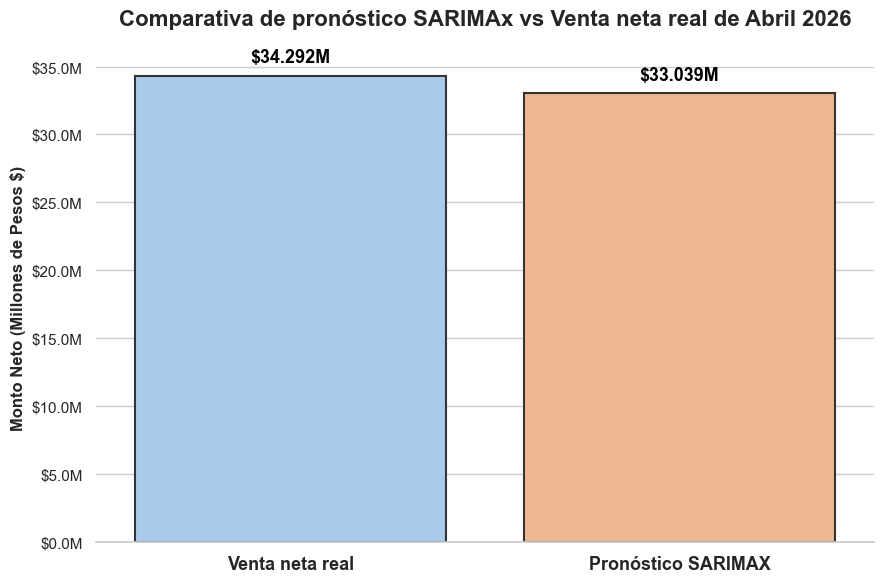

In [34]:
total_real_abril = y_val_scaled.sum()
total_pred_abril = pred_val.sum()

df_reporte_abril = pd.DataFrame({
    'Tipo': ['Venta neta real', 'Pronóstico SARIMAX'],
    'Monto ($M)': [total_real_abril, total_pred_abril]
})

sns.set_theme(style="whitegrid", palette="pastel")

plt.figure(figsize=(9, 6), dpi=100)

ax = sns.barplot(
    data=df_reporte_abril,
    x='Tipo', 
    y='Monto ($M)',
    hue='Tipo',
    legend=False,
    edgecolor=".2",
    linewidth=1.5
)


plt.title('Comparativa de pronóstico SARIMAx vs Venta neta real de Abril 2026', 
          fontsize=16, fontweight='bold', pad=20, family='Arial')

plt.xlabel('')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=13, fontweight='bold')

formatter = ticker.StrMethodFormatter('${x:.1f}M')
ax.yaxis.set_major_formatter(formatter)


for p in ax.patches:

    height = p.get_height()

    ax.annotate(f'${height:.3f}M', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 7), 
                textcoords='offset points')

sns.despine(left=True, bottom=False)


plt.tight_layout()

plt.show()

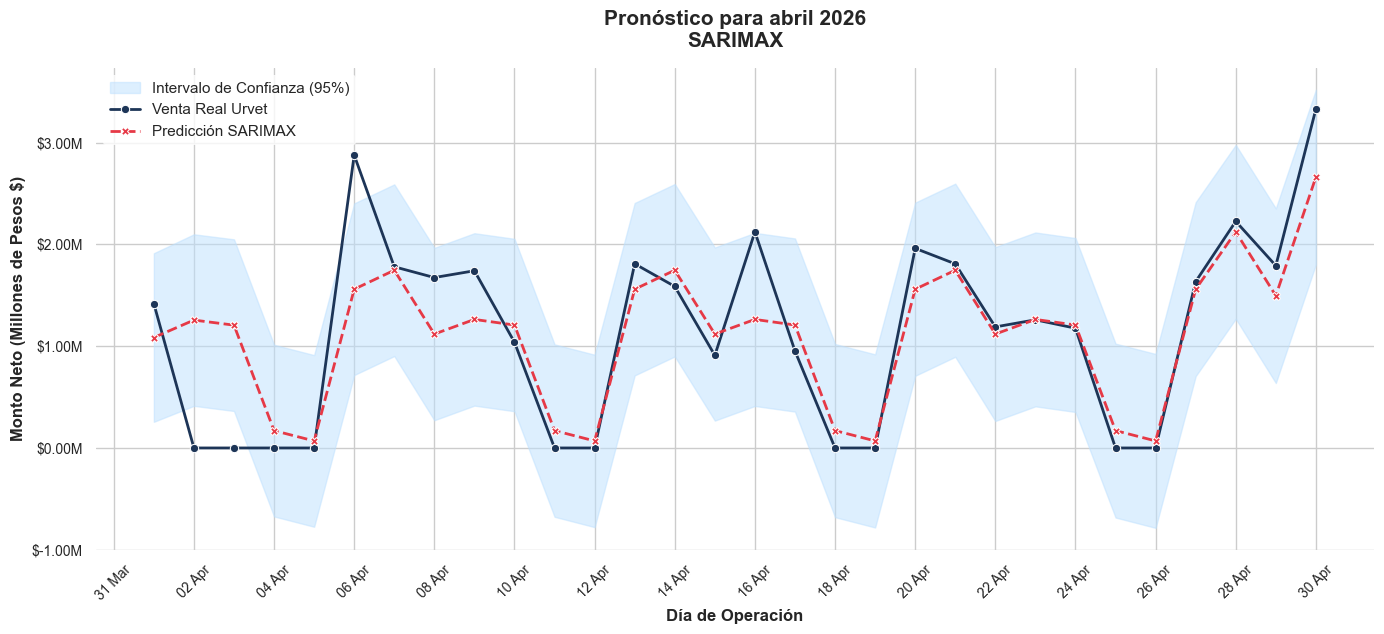

In [40]:
df_ci_completo = forecast_objeto.conf_int(alpha=0.05)

ci_lower_april = df_ci_completo.iloc[:, 0].loc[validation_start:validation_end]
ci_upper_april = df_ci_completo.iloc[:, 1].loc[validation_start:validation_end]


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6.5), dpi=100)

plt.fill_between(
    pred_val.index, 
    ci_lower_april, 
    ci_upper_april, 
    color='#bde0fe', 
    alpha=0.5, 
    label='Intervalo de Confianza (95%)'
)

sns.lineplot(
    x=y_val_scaled.index, 
    y=y_val_scaled.values, 
    marker='o', 
    markersize=6,
    color='#1d3557', 
    linewidth=2, 
    label='Venta Real Urvet'
)

sns.lineplot(
    x=pred_val.index, 
    y=pred_val.values, 
    marker='X', 
    markersize=6,
    color='#e63946', 
    linewidth=2, 
    linestyle='--', 
    label='Predicción SARIMAX'
)

plt.title('Pronóstico para abril 2026\nSARIMAX', 
          fontsize=15, fontweight='bold', pad=15, family='Arial')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xlabel('Día de Operación', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.2f}M"))
plt.yticks(fontsize=10)

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [41]:
may_days = pd.date_range(start="2026-05-01", end="2026-05-31", freq='D')
X_may = pd.DataFrame(index=may_days)

holidays = ['2026-05-01']
X_may['non_work_day'] = X_may.index.strftime('%Y-%m-%d').isin(holidays).astype(int)
is_weekend_may = X_may.index.weekday.isin([5, 6])
X_may['is_workday'] = ~(is_weekend_may | (X_may['non_work_day'] == 1))

X_may['is_month_end'] = 0
X_may['close_month_zone'] = 0

work_days_may = X_may[X_may['is_workday']].index
if len(work_days_may) >= 1:
    X_may.loc[work_days_may[-1], 'is_month_end'] = 1
if len(work_days_may) >= 3:
    X_may.loc[work_days_may[-3:-1], 'close_month_zone'] = 1


X_test_extended = X_may[['is_month_end', 'close_month_zone']]
X_total_future = pd.concat([X_val, X_test_extended])
X_total_future = X_total_future[['is_month_end', 'close_month_zone']]


forecast_total_obj = fit_res_6.get_forecast(steps=len(X_total_future), exog=X_total_future)
forecast_total_future = forecast_total_obj.predicted_mean
df_ci_total = forecast_total_obj.conf_int(alpha=0.05)

pred_test_extended = forecast_total_future['2026-05-01':'2026-05-31']
ci_lower_may_ext = df_ci_total.iloc[:, 0].loc['2026-05-01':'2026-05-31']
ci_upper_may_ext = df_ci_total.iloc[:, 1].loc['2026-05-01':'2026-05-31']

display(ci_lower_may_ext)
display(ci_upper_may_ext)


2026-05-01    0.35015056
2026-05-02   -0.68709974
2026-05-03   -0.78863090
2026-05-04    0.70207406
2026-05-05    0.88854415
2026-05-06    0.25798411
2026-05-07    0.40165187
2026-05-08    0.34654781
2026-05-09   -0.69070248
2026-05-10   -0.79223364
2026-05-11    0.69847131
2026-05-12    0.88494140
2026-05-13    0.25439584
2026-05-14    0.39806411
2026-05-15    0.34296007
2026-05-16   -0.69429023
2026-05-17   -0.79582139
2026-05-18    0.69488357
2026-05-19    0.88135366
2026-05-20    0.25082240
2026-05-21    0.39449116
2026-05-22    0.33938714
2026-05-23   -0.69786315
2026-05-24   -0.79939431
2026-05-25    0.69131065
2026-05-26    0.87778074
2026-05-27    0.62403249
2026-05-28    0.76770176
2026-05-29    1.73476886
2026-05-30   -0.70142143
2026-05-31   -0.80295260
Freq: D, Name: lower net_price, dtype: float64

2026-05-01   2.06577315
2026-05-02   1.02852317
2026-05-03   0.92699202
2026-05-04   2.41769698
2026-05-05   2.60416706
2026-05-06   1.98055687
2026-05-07   2.12447119
2026-05-08   2.06937589
2026-05-09   1.03212592
2026-05-10   0.93059476
2026-05-11   2.42129972
2026-05-12   2.60776981
2026-05-13   1.98414514
2026-05-14   2.12805895
2026-05-15   2.07296364
2026-05-16   1.03571366
2026-05-17   0.93418251
2026-05-18   2.42488747
2026-05-19   2.61135755
2026-05-20   1.98771859
2026-05-21   2.13163189
2026-05-22   2.07653656
2026-05-23   1.03928658
2026-05-24   0.93775543
2026-05-25   2.42846039
2026-05-26   2.61493047
2026-05-27   2.36804628
2026-05-28   2.51195909
2026-05-29   3.47903485
2026-05-30   1.04284487
2026-05-31   0.94131371
Freq: D, Name: upper net_price, dtype: float64

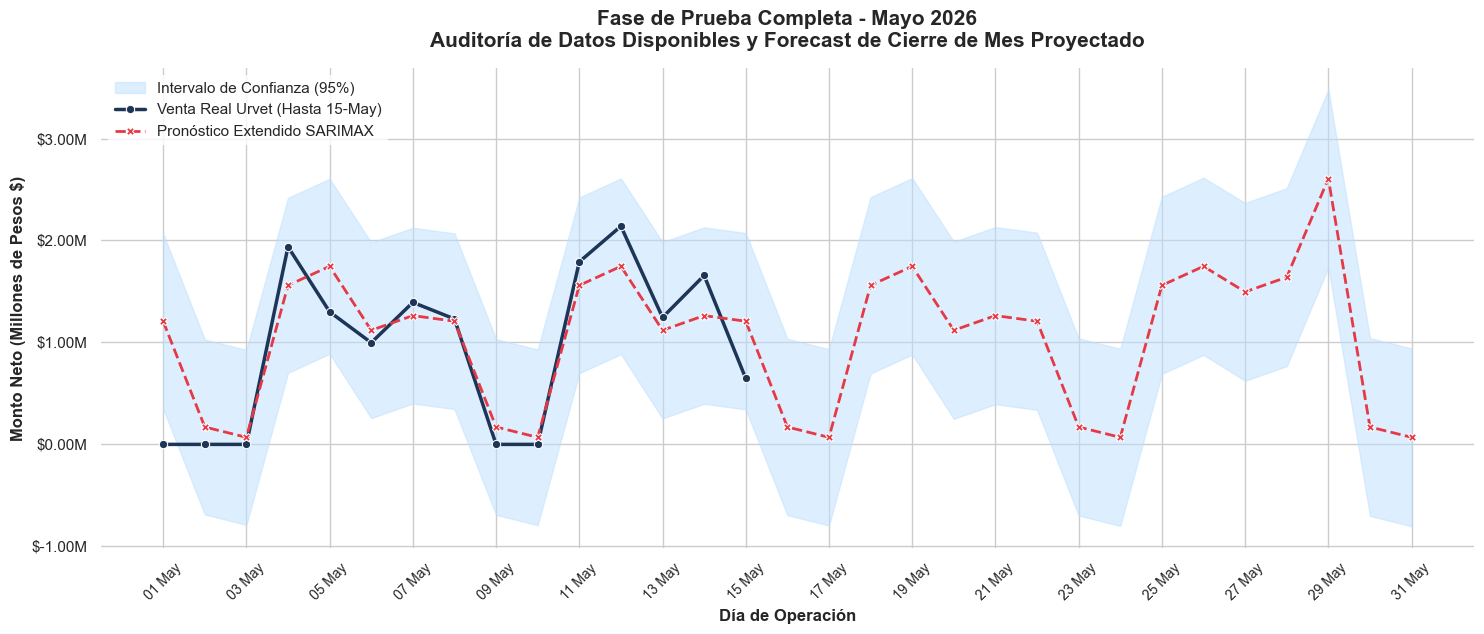

In [45]:
y_test = y_scaled['2026-05-01':'2026-05-31']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6.5), dpi=100)


plt.fill_between(
    pred_test_extended.index, 
    ci_lower_may_ext, 
    ci_upper_may_ext, 
    color='#bde0fe', 
    alpha=0.5, 
    label='Intervalo de Confianza (95%)'
)

sns.lineplot(
    x=y_test.index, 
    y=y_test.values, 
    marker='o', 
    markersize=6,
    color='#1d3557', 
    linewidth=2.5, 
    label='Venta Real Urvet (Hasta 15-May)'
)

sns.lineplot(
    x=pred_test_extended.index, 
    y=pred_test_extended.values, 
    marker='X', 
    markersize=6,
    color='#e63946', 
    linewidth=2, 
    linestyle='--', 
    label='Pronóstico Extendido SARIMAX'
)
plt.title('Fase de Prueba Completa - Mayo 2026\nAuditoría de Datos Disponibles y Forecast de Cierre de Mes Proyectado', 
          fontsize=15, fontweight='bold', pad=15, family='Arial')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xlabel('Día de Operación', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.2f}M"))
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

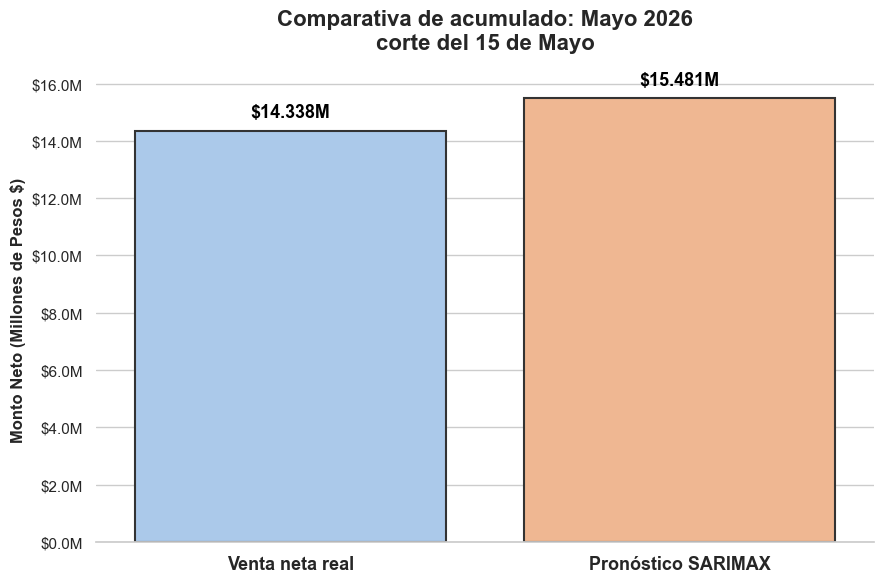

In [47]:
total_real_mayo_parcial = y_test.sum()

total_pred_mayo_parcial = pred_test_extended.loc[y_test.index].sum()

df_reporte_mayo = pd.DataFrame({
    'Tipo': ['Venta neta real', 'Pronóstico SARIMAX'],
    'Monto ($M)': [total_real_mayo_parcial, total_pred_mayo_parcial]
})

sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(9, 6), dpi=100)

ax = sns.barplot(
    data=df_reporte_mayo,
    x='Tipo', 
    y='Monto ($M)',
    hue='Tipo',
    legend=False,
    edgecolor=".2",
    linewidth=1.5
)

plt.title('Comparativa de acumulado: Mayo 2026\ncorte del 15 de Mayo', 
          fontsize=16, fontweight='bold', pad=20, family='Arial')

plt.xlabel('')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=13, fontweight='bold')

formatter = ticker.StrMethodFormatter('${x:.1f}M')
ax.yaxis.set_major_formatter(formatter)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:.3f}M', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 7), 
                textcoords='offset points')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()